In [1]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

# 2. Load Dataset
df = pd.read_csv("netflix_titles.csv")

In [2]:
# Basic info
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

First 5 rows:
   show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 2

In [3]:
# 3. Data Cleaning
# Fill missing values (Best Practice)
cols = ['director', 'cast', 'country', 'rating']
df[cols] = df[cols].fillna('Unknown')

# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year added
df['year_added'] = df['date_added'].dt.year

# Remove duplicates if any
df.drop_duplicates(inplace=True)

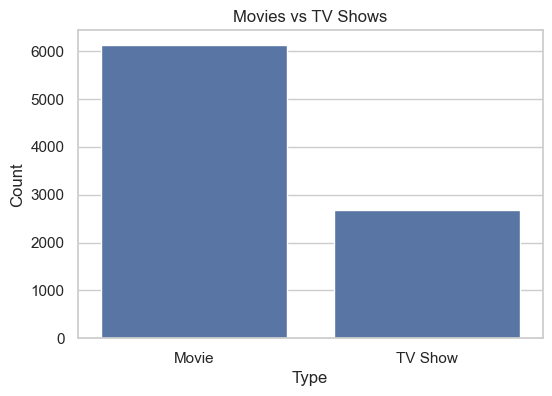

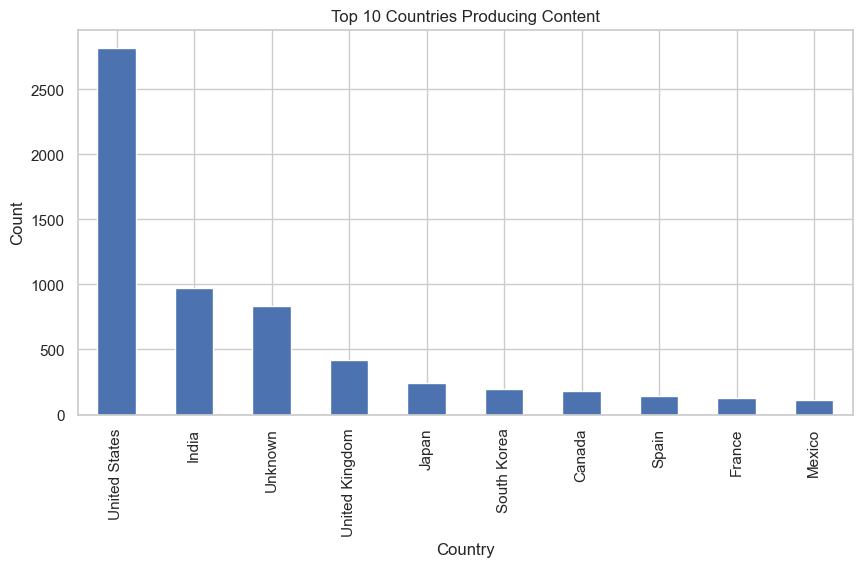

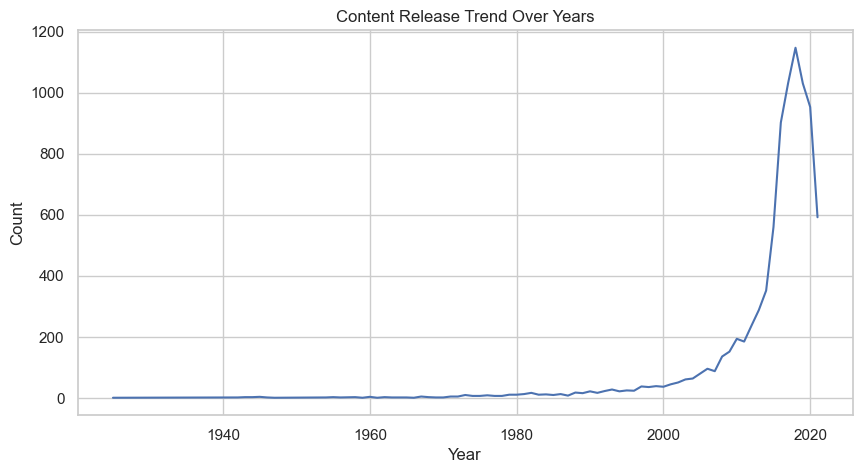

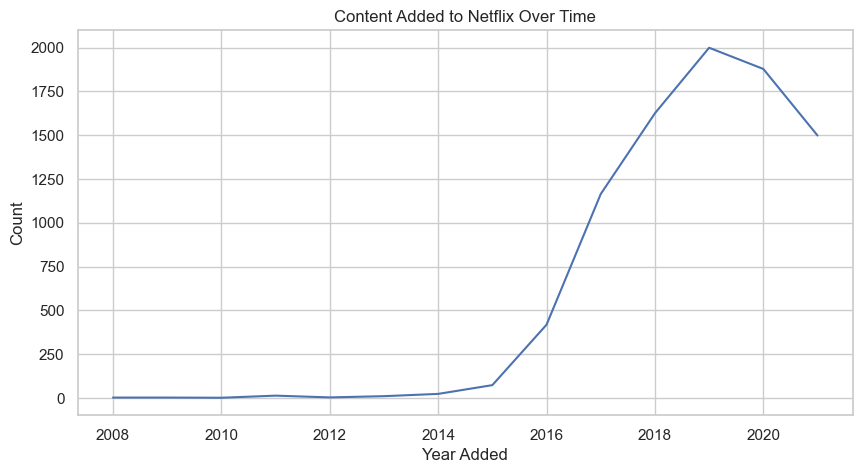

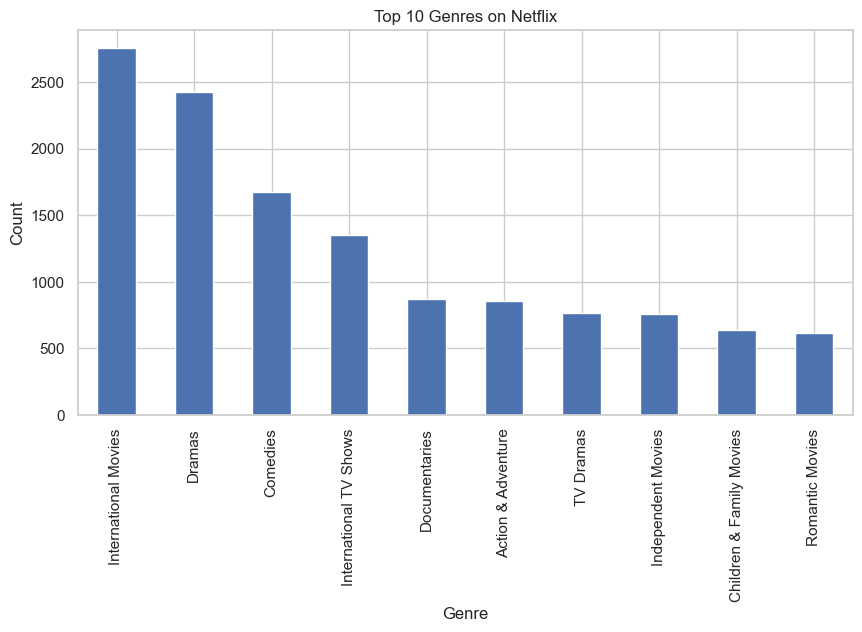

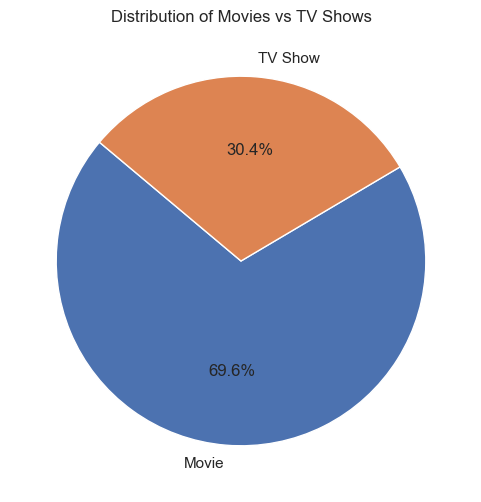

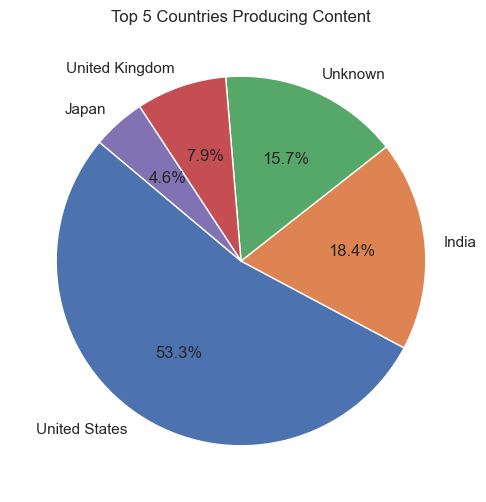

In [4]:
# Exploratory Data Analysis


# 1. Movies vs TV Shows
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# 2. Top 10 Countries
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# 3. Release Year Trend
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# 4. Content Added Over Time
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added to Netflix Over Time")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()

# 5. Top Genres
genres = df['listed_in'].str.split(', ', expand=True).stack()
plt.figure(figsize=(10,5))
genres.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()
# Count values
type_counts = df['type'].value_counts()

# Plot Pie Chart
plt.figure(figsize=(6,6))
plt.pie(type_counts, 
        labels=type_counts.index, 
        autopct='%1.1f%%', 
        startangle=140)

plt.title("Distribution of Movies vs TV Shows")
plt.show()

#  plot pie of top 5 countries
top_countries = df['country'].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(top_countries, 
        labels=top_countries.index, 
        autopct='%1.1f%%', 
        startangle=140)

plt.title("Top 5 Countries Producing Content")
plt.show()

In [5]:
# 5. Insights

movies_count = len(df[df['type'] == 'Movie'])
tv_count = len(df[df['type'] == 'TV Show'])

print("\nTotal Movies:", movies_count)
print("Total TV Shows:", tv_count)

print("\nMost Common Ratings:")
print(df['rating'].value_counts().head())

print("\nTop 5 Genres:")
print(genres.value_counts().head())


Total Movies: 6131
Total TV Shows: 2676

Most Common Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

Top 5 Genres:
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64
